# Analysis & models

In this notebook, we will analyze and do some predictive modeling on our combined utility rate, climate, and election data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
from matplotlib.colors import LinearSegmentedColormap
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("../data/processed/utility-climate-election.csv", 
                 dtype={"county_fips": str})

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (3089, 14)
Columns: ['county_fips', 'state', 'county_name', 'dem_votes', 'rep_votes', 'totalvotes', 'rep_share', 'dem_share', 'rep_margin', 'cdd_annual', 'hdd_annual', 'county_res_rate', 'avg_consumption', 'monthly_bill']


,county_fips,state,county_name,dem_votes,rep_votes,totalvotes,rep_share,dem_share,rep_margin,cdd_annual,hdd_annual,county_res_rate,avg_consumption,monthly_bill
0,01001,Alabama,Autauga,7439.0,20484.0,28281,0.724303,0.263039,0.461264,2513,2003,0.167074,1143.1996,190.999412
1,01003,Alabama,Baldwin,24934.0,95798.0,122249,0.783630,0.203961,0.579669,3055,1355,0.142042,1143.1996,162.382048
2,01005,Alabama,Barbour,4158.0,5606.0,9855,0.568848,0.421918,0.146930,2526,1811,0.161961,1143.1996,185.154120
3,01007,Alabama,Bibb,1619.0,7572.0,9257,0.817976,0.174895,0.643081,2294,2212,0.164650,1143.1996,188.227698
4,01009,Alabama,Blount,2576.0,25354.0,28163,0.900259,0.091468,0.808792,2040,2544,0.159236,1143.1996,182.038286


In [3]:
df["lean"] = df["rep_margin"].apply(lambda x: "Republican" if x > 0 else "Democratic")

## Correlation matrix

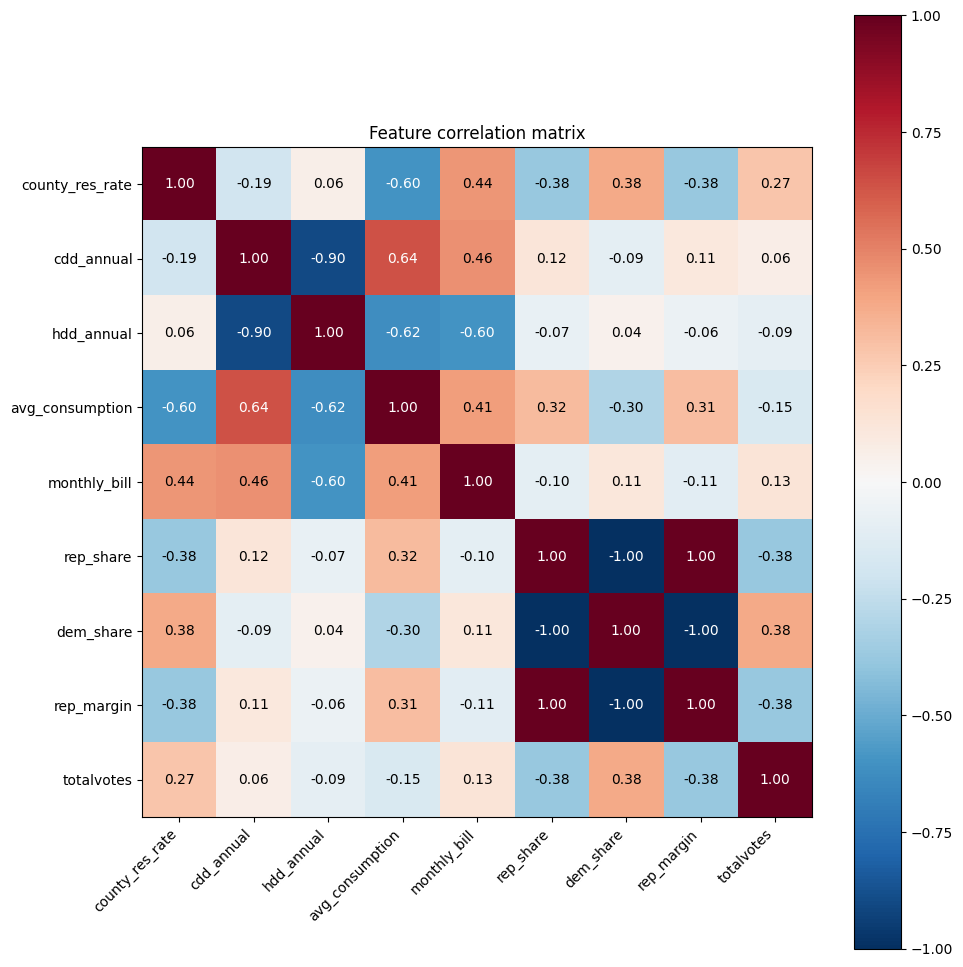

In [4]:
features = ["county_res_rate", "cdd_annual", "hdd_annual", "avg_consumption", "monthly_bill",
            "rep_share", "dem_share", "rep_margin", "totalvotes"]
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

plt.colorbar(im, ax=ax)

for i in range(len(features)):
    for j in range(len(features)):
        value = corr.iloc[i, j]
        color = "white" if abs(value) > 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color)

ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

Takeaways:

1. Climate has a weak relationship with rates at the county level.
CDD correlates with rate at −0.19; HDD at +0.06. Neither is strong. Hot counties (higher CDD) pay slightly less on average, cold counties (higher HDD) show essentially no relationship. This indicates that climate is not the primary driver of rate variation.

2. Politics correlates more strongly with rate than climate does. Republican vote share correlates with rate at −0.38; Democratic share at +0.38. This is descriptive, not causal. It likely reflects that Democratic-leaning counties cluster in expensive states (CA, NY, MA), and that large urban areas are typically Democrat-leaning.

3. Total votes is a mild positive predictor (r = +0.27). Larger counties (more voters, proxy for population) pay slightly higher rates. This is likely because large urban counties cluster in expensive coastal states.

4. CDD correlates positively (0.64) with consumption. Higher CDD indicates higher demand for air conditioning, which is electric. HDD correlates negatively (-0.62) with consumption. Heating often uses gas rather than electricity. Also, areas with higher demand for heat will typically have colder climates, leading to less usage of air conditioning, which is electric. As a result, areas with high demand for heat will typically have lower consumption of electricity for AC.

5. Consumption and monthly bills correlate (0.41), as expected. Political leaning correlates stronger with rate than monthly bill. This is because rates are indicative of policy, while monthly bills are indicative of policy but also climate and demand.

6. rep_share correlates positively (0.32) with consumption, while dem_share correlates negatively (-0.30) with consumption. Red states use more electricity than blue states, which influences monthly bills.

# Analysis

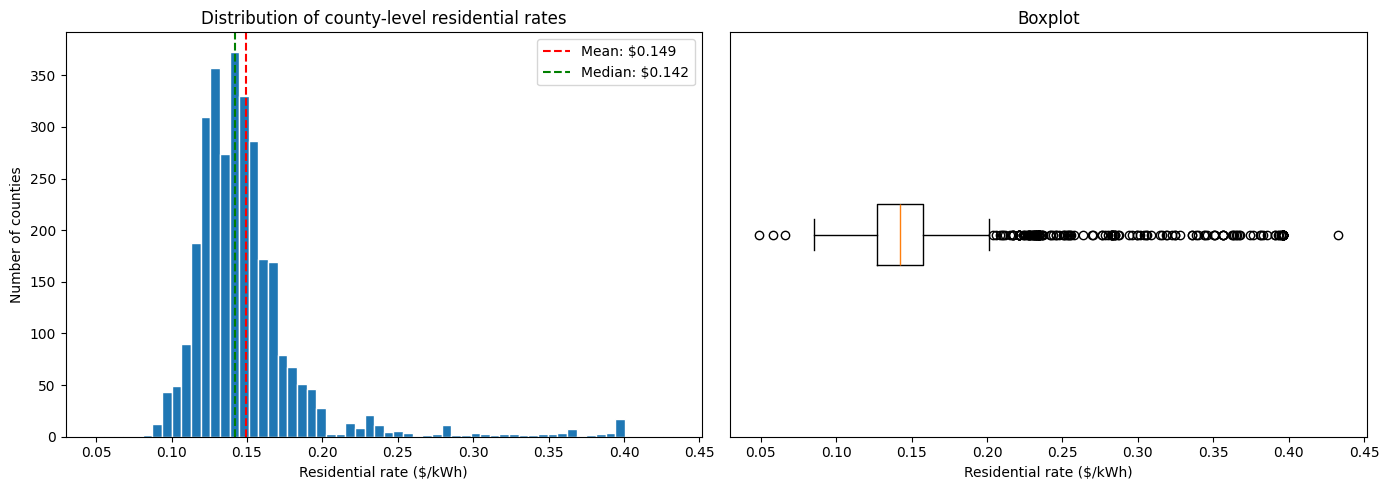

count    3089.000000
mean        0.149336
std         0.041533
min         0.048969
25%         0.127030
50%         0.142384
75%         0.157612
max         0.432490
Name: county_res_rate, dtype: float64


In [5]:
# plot the distribution of utility rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df["county_res_rate"], bins=60, edgecolor="white")
axes[0].axvline(df["county_res_rate"].mean(), color="red", linestyle="--", label=f"Mean: ${df['county_res_rate'].mean():.3f}")
axes[0].axvline(df["county_res_rate"].median(), color="green", linestyle="--", label=f"Median: ${df['county_res_rate'].median():.3f}")
axes[0].set_xlabel("Residential rate ($/kWh)")
axes[0].set_ylabel("Number of counties")
axes[0].set_title("Distribution of county-level residential rates")
axes[0].legend()

# boxplot
axes[1].boxplot(df["county_res_rate"], vert=False)
axes[1].set_xlabel("Residential rate ($/kWh)")
axes[1].set_title("Boxplot")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(df["county_res_rate"].describe())

In [6]:
expensive_states = df[df['county_res_rate'] > 0.25]['state'].unique()
df[df['state'].isin(expensive_states)].groupby('state')['county_res_rate'].mean()

state
California       0.348203
Connecticut      0.284862
Maine            0.235128
Massachusetts    0.305909
Michigan         0.196755
New York         0.202429
Rhode Island     0.281743
Name: county_res_rate, dtype: float64

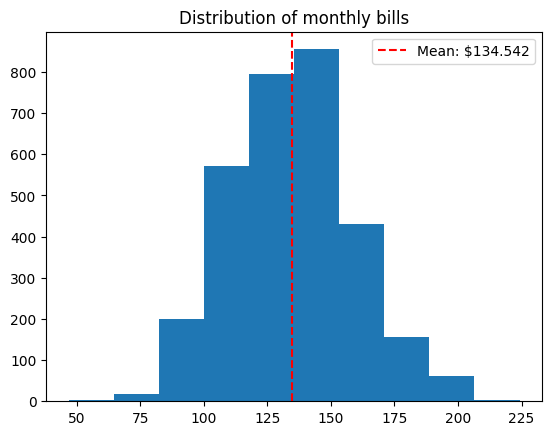

In [7]:
plt.title("Distribution of monthly bills")
plt.hist(df['monthly_bill'])
plt.axvline(df["monthly_bill"].mean(), color="red", linestyle="--", label=f"Mean: ${df['monthly_bill'].mean():.3f}")
plt.legend()

The average electricity rate is $0.149 /kWh. We have some outliers. These come from a handful of expensive states (California, Connecticut, Maine, Massachusetts, Michigan, New York, and Rhode Island).

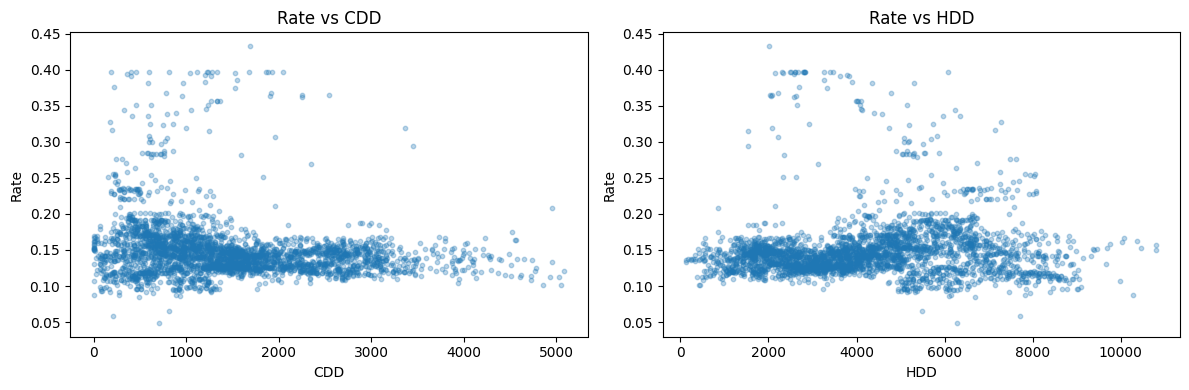

In [8]:
# plot utility rates vs. cooling & heating degree days
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["cdd_annual"], df["county_res_rate"], alpha=0.3, s=10)
axes[0].set_xlabel("CDD")
axes[0].set_ylabel("Rate")
axes[0].set_title("Rate vs CDD")

axes[1].scatter(df["hdd_annual"], df["county_res_rate"], alpha=0.3, s=10)
axes[1].set_xlabel("HDD")
axes[1].set_ylabel("Rate")
axes[1].set_title("Rate vs HDD")

plt.tight_layout()
plt.show()

These scatterplots demonstrate the weak relationships between rates and CDD and HDD, as was demonstrated by correlation matrix.

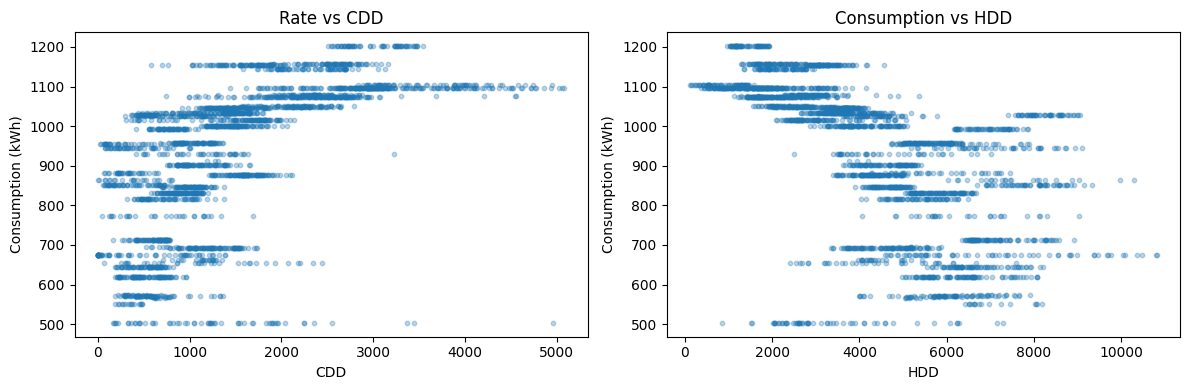

In [9]:
# plot utility rates vs. cooling & heating degree days
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["cdd_annual"], df["avg_consumption"], alpha=0.3, s=10)
axes[0].set_xlabel("CDD")
axes[0].set_ylabel("Consumption (kWh)")
axes[0].set_title("Rate vs CDD")

axes[1].scatter(df["hdd_annual"], df["avg_consumption"], alpha=0.3, s=10)
axes[1].set_xlabel("HDD")
axes[1].set_ylabel("Consumption (kWh)")
axes[1].set_title("Consumption vs HDD")

plt.tight_layout()
plt.show()

CDD (cooling demand) correlates with higher electricity consumption. HDD (heating demand) correlates with lower electricity consumption.

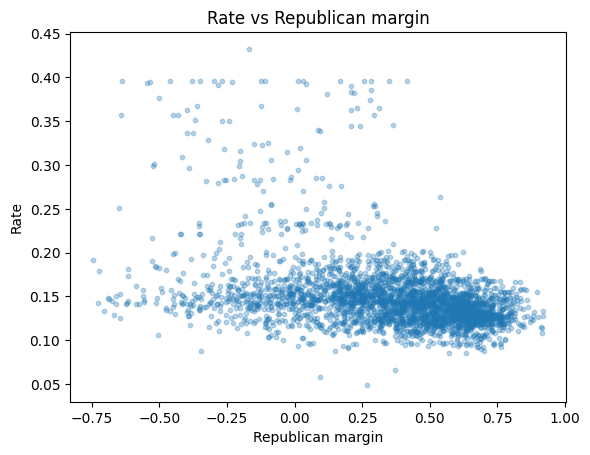

In [10]:
# plot rates vs. political leaning
plt.scatter(df["rep_margin"], df["county_res_rate"], alpha=0.3, s=10)
plt.xlabel("Republican margin")
plt.ylabel("Rate")
plt.title("Rate vs Republican margin")
plt.show()

Here, we can see the somewhat weak relationship between higher Republican margin and lower rates. This is only descriptive.

In [11]:
state_summary = (
    df.groupby("state")
    .agg(
        mean_rate=("county_res_rate", "mean"),
        std_rate=("county_res_rate", "std"),
        total_dem=("dem_votes", "sum"),
        total_rep=("rep_votes", "sum"),
        total_votes=("totalvotes", "sum"),
    )
)
state_summary["state_dem_share"] = state_summary["total_dem"] / state_summary["total_votes"]
state_summary["state_rep_share"] = state_summary["total_rep"] / state_summary["total_votes"]
# state_summary["state_lean"] = state_summary["state_rep_share"] > state_summary["state_dem_share"]

state_summary = state_summary.sort_values("mean_rate")

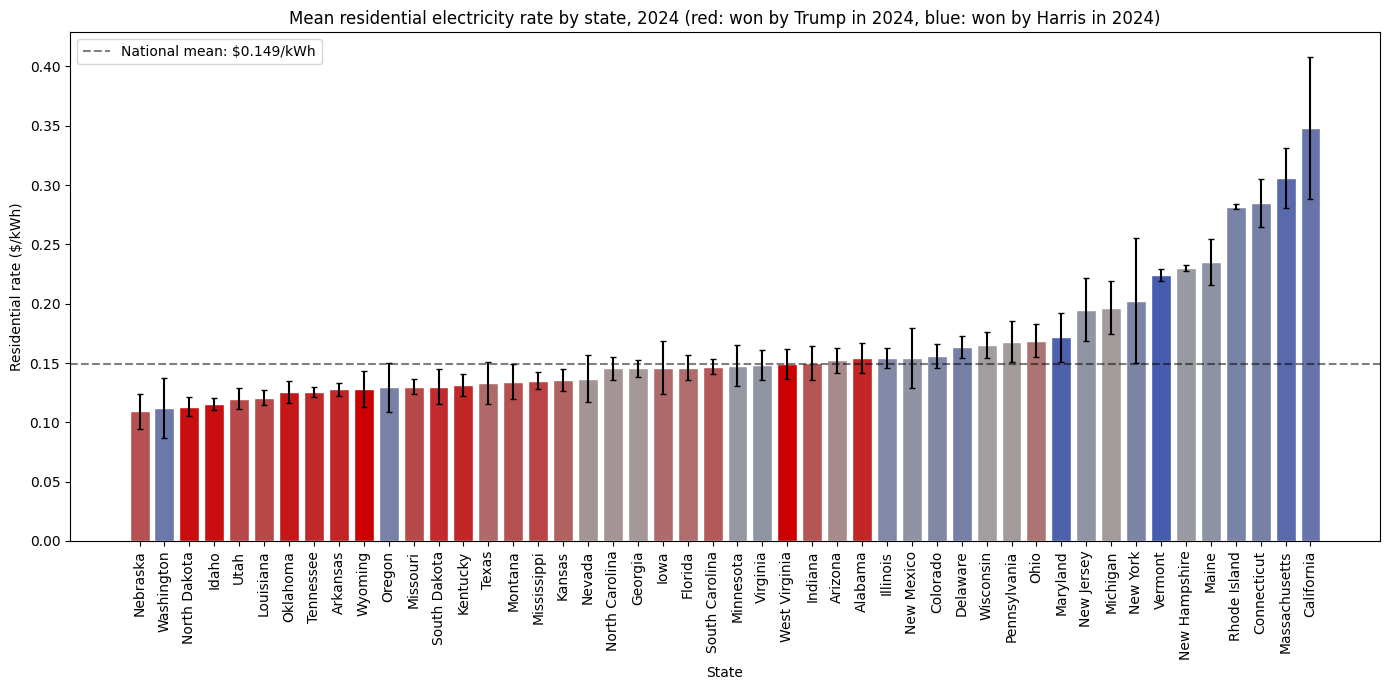

In [12]:
# create a gradient from blue - gray - red to show political affiliations
cmap = LinearSegmentedColormap.from_list(
    "BlueGrayRed",
    ["#2d48b2", "#a1a1a1", "#cc0001"]
)

margins = state_summary["state_rep_share"] - state_summary["state_dem_share"]
norm = plt.Normalize(vmin=-0.4, vmax=0.4)
colors = cmap(norm(margins))

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(state_summary.index, state_summary["mean_rate"],
       yerr=state_summary["std_rate"],
       capsize=2, edgecolor="white", color=colors)

national_mean = df["county_res_rate"].mean()
ax.axhline(national_mean, color="black", linestyle="--", alpha=0.5,
           label=f"National mean: ${national_mean:.3f}/kWh")

ax.set_xlabel("State")
ax.set_ylabel("Residential rate ($/kWh)")
ax.set_title("Mean residential electricity rate by state, 2024 (red: won by Trump in 2024, blue: won by Harris in 2024)")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Takeaways:

1. The cheapest state (Nebraska, ~\\$0.11/kWh) and the most expensive (California, ~\\$0.35/kWh) differ by more than 3x. This is a massive difference and indicates an effect of state-level policies.

2. The partisan gradient - the cheapest 10 states are nearly all red. The most expensive 10 states are entirely blue. Color sweeps from red on the left to blue on the right almost perfectly, with swing states transitioning through the middle. This visual alone establishes the partisan-rate correlation that motivates the rest of the analysis.

3. The middle of the chart (Texas, Iowa, Florida, Georgia, Virginia, Indiana) sits right around the national mean of $0.149/kWh. These are mostly purple states with mixed politics, mixed fuel mixes, and traditionally regulated utility markets. They form a natural baseline that the extremes deviate from.

### Rates in Republican-majority counties vs Democrat-majority counties

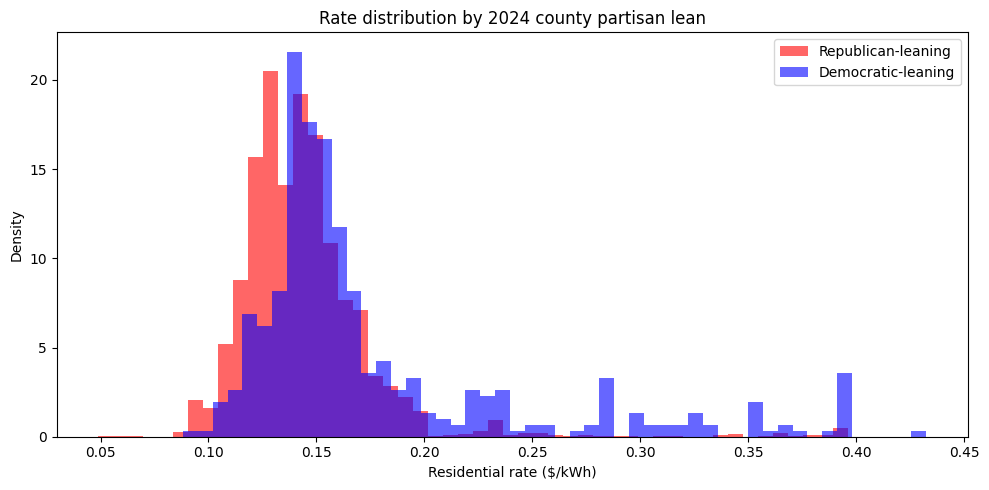

             count   mean    std    min    25%    50%    75%    max
lean                                                               
Democratic   444.0  0.177  0.066  0.088  0.141  0.152  0.183  0.432
Republican  2645.0  0.145  0.034  0.049  0.126  0.140  0.155  0.396


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df.loc[df["lean"] == "Republican", "county_res_rate"], 
        bins=50, alpha=0.6, color="red", label="Republican-leaning", density=True)
ax.hist(df.loc[df["lean"] == "Democratic", "county_res_rate"], 
        bins=50, alpha=0.6, color="blue", label="Democratic-leaning", density=True)

ax.set_xlabel("Residential rate ($/kWh)")
ax.set_ylabel("Density")
ax.set_title("Rate distribution by 2024 county partisan lean")
ax.legend()
plt.tight_layout()
plt.show()

# Quick numeric summary
print(df.groupby("lean")["county_res_rate"].describe().round(3))

Blue counties have an average rate of \\$0.177/ kWH, while red counties have an average rate of \\$0.145 / kWh.

In [14]:
above_20 = df[df['county_res_rate'] > 0.20]

red_count, blue_count = 0, 0

print(f"{'State':<20} | {'2024 Political Leaning':<12}")
print("-" * 35)

for state in above_20['state'].unique():
    is_rep = state_summary.loc[state, 'state_rep_share'] > state_summary.loc[state, 'state_dem_share']
    affil = 'Republican' if is_rep else 'Democrat'
    if affil == 'Republican':
        red_count += 1
    else:
        blue_count += 1
    
    # formatted print
    print(f"{state:<20} | {affil:<12}")

print("-" * 35)
print(f"Total: Red states: {red_count} | Blue states {blue_count}")

State                | 2024 Political Leaning
-----------------------------------
California           | Democrat    
Connecticut          | Democrat    
Maine                | Democrat    
Massachusetts        | Democrat    
Michigan             | Republican  
New Hampshire        | Democrat    
New Jersey           | Democrat    
New Mexico           | Democrat    
New York             | Democrat    
Pennsylvania         | Republican  
Rhode Island         | Democrat    
Vermont              | Democrat    
-----------------------------------
Total: Red states: 2 | Blue states 10


In [15]:
below_12 = df[df['county_res_rate'] < 0.12]

red_count, blue_count = 0, 0

print(f"{'State':<20} | {'2024 Political Leaning':<12}")
print("-" * 35)

for state in below_12['state'].unique():
    is_rep = state_summary.loc[state, 'state_rep_share'] > state_summary.loc[state, 'state_dem_share']
    affil = 'Republican' if is_rep else 'Democrat'
    
    if affil == 'Republican':
        red_count += 1
    else:
        blue_count += 1
    
    # formatted print
    print(f"{state:<20} | {affil:<12}")

print("-" * 35)
print(f"Total: Red states: {red_count} | Blue states {blue_count}")

State                | 2024 Political Leaning
-----------------------------------
Alabama              | Republican  
Arkansas             | Republican  
Idaho                | Republican  
Illinois             | Democrat    
Iowa                 | Republican  
Kansas               | Republican  
Kentucky             | Republican  
Louisiana            | Republican  
Minnesota            | Democrat    
Mississippi          | Republican  
Missouri             | Republican  
Montana              | Republican  
Nebraska             | Republican  
Nevada               | Republican  
New Mexico           | Democrat    
North Dakota         | Republican  
Oklahoma             | Republican  
Oregon               | Democrat    
South Dakota         | Republican  
Tennessee            | Republican  
Texas                | Republican  
Utah                 | Republican  
Virginia             | Democrat    
Washington           | Democrat    
Wyoming              | Republican  
------------------

Takeaways:
1. The bulk of both distributions overlap heavily. Most counties — both red and blue — pay between \\$0.10 and \\$0.18/kWh. The cores of both distributions sit on top of each other in the \\$0.13–\\$0.16 range. For typical counties, partisan composition is not a strong discriminator of rates.

2. Above \\$ 0.20/kWh, the distribution is almost entirely blue. 10 of the 12 states that have counties with rates above \\$0.20 were blue states in 2024. Below \\$0.12, 19 of the 25 states were red in 2024.

3. The Republican distribution is tighter and lower-centered.
Mean: \\$0.145/kWh. Standard deviation: \\$0.034. Republican counties cluster around the median with relatively little spread.
The Democratic distribution is wider and higher-centered. Mean: \\$0.177/kWh. Standard deviation: \\$0.066 — nearly 2x as wide. This reflects the bimodal nature of Democratic counties: many sit in the central pack with everyone else, but a meaningful subset sits in the extreme right tail.

4. The difference between the means (\\$0.032/kWh, or about 22%) is real but smaller than the visual suggests.
The right tail makes the Democratic distribution look very different, but the medians (\\$0.140 vs \\$0.152) only differ by about \\$0.012/kWh — about 8%. Most of the mean gap is driven by the right tail, not by a uniform shift across all counties. If you removed the highest-rate Democratic counties (urban CA, urban NY, etc.), the distributions would look much more similar.

5. The Democratic right tail is geographically concentrated: a handful of expensive states (CA, NY, MA, CT, RI) contribute most of those high-rate Democratic counties. It's not as much "Democratic counties pay more" as it is "the most expensive states happen to lean Democratic, and their Democratic counties pull the partisan average up."

### Monthly bills in Republican-majority counties vs Democrat-majority counties

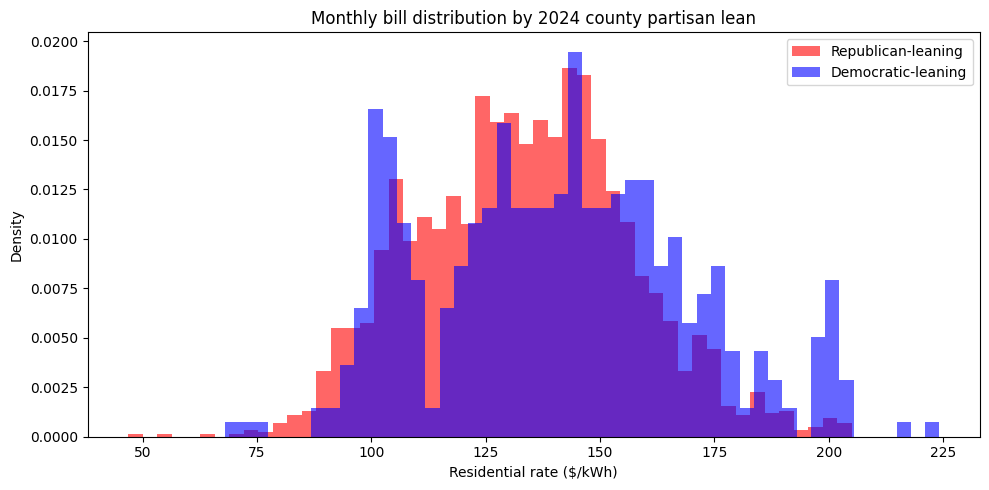

             count     mean     std     min      25%      50%      75%  \
lean                                                                     
Democratic   444.0  141.008  28.508  68.072  120.296  140.887  159.556   
Republican  2645.0  133.456  23.257  46.788  116.721  133.684  148.641   

                max  
lean                 
Democratic  224.219  
Republican  205.012  


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df.loc[df["lean"] == "Republican", "monthly_bill"], 
        bins=50, alpha=0.6, color="red", label="Republican-leaning", density=True)
ax.hist(df.loc[df["lean"] == "Democratic", "monthly_bill"], 
        bins=50, alpha=0.6, color="blue", label="Democratic-leaning", density=True)

ax.set_xlabel("Residential rate ($/kWh)")
ax.set_ylabel("Density")
ax.set_title("Monthly bill distribution by 2024 county partisan lean")
ax.legend()
plt.tight_layout()
plt.show()

# Quick numeric summary
print(df.groupby("lean")["monthly_bill"].describe().round(3))

Here, we see less of a shift between the distributions of monthly bills for red and blue states. The distinction is blurred by the fact that other factors play a role in monthly bills, such as consumption, which is tied to climate.

In [17]:
df['monthly_bill'].describe()

count    3089.000000
mean      134.541605
std        24.222239
min        46.787981
25%       117.225382
50%       134.579687
75%       150.184070
max       224.218855
Name: monthly_bill, dtype: float64

## Modeling

#### Predicting county_res_rate using rep_margin

In [18]:
x = df[['rep_margin']]
y = df['county_res_rate']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Train: {len(x_train):,} counties")
print(f"Test:  {len(x_test):,} counties")

Train: 2,471 counties
Test:  618 counties


In [19]:
model = LinearRegression()
model.fit(x_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients: {model.coef_}")

Intercept: 0.1677
Coefficients: [-0.05233023]


In [20]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

print(f"Train R^2:  {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R^2:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MAE: ${mean_absolute_error(y_train, y_pred_train):.4f}/kWh")
print(f"Test MAE:  ${mean_absolute_error(y_test, y_pred_test):.4f}/kWh")

Train R^2:  0.1532
Test R^2:   0.1139
Train MAE: $0.0230/kWh
Test MAE:  $0.0251/kWh


rep_margin accounts for 11.39% of the variance of county_res_rate

#### Predicting county_res_rate using avg_consumption

In [21]:
x = df[['avg_consumption']]
y = df['county_res_rate']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Train: {len(x_train):,} counties")
print(f"Test:  {len(x_test):,} counties")

Train: 2,471 counties
Test:  618 counties


In [22]:
model = LinearRegression()
model.fit(x_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients: {model.coef_}")

Intercept: 0.2736
Coefficients: [-0.00013387]


In [23]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

print(f"Train R^2:  {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R^2:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MAE: ${mean_absolute_error(y_train, y_pred_train):.4f}/kWh")
print(f"Test MAE:  ${mean_absolute_error(y_test, y_pred_test):.4f}/kWh")

Train R^2:  0.3517
Test R^2:   0.3701
Train MAE: $0.0215/kWh
Test MAE:  $0.0221/kWh


avg_consumption accounts for 37.01% of the variance of county_res_rate

#### Predicting county_res_rate using state

In [24]:
state_dummies = pd.get_dummies(df['state'])
x = state_dummies
y = df['county_res_rate']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Train: {len(x_train):,} counties")
print(f"Test:  {len(x_test):,} counties")

Train: 2,471 counties
Test:  618 counties


In [25]:
model = LinearRegression()
model.fit(x_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients: {model.coef_}")

Intercept: 0.1631
Coefficients: [-0.00887646 -0.01311214 -0.03579635  0.18595824 -0.00814142  0.1220741
  0.00278769 -0.01687452 -0.0170235  -0.04839614 -0.00916966 -0.01302136
 -0.01862368 -0.02668144 -0.03181115 -0.04313358  0.07041279  0.00486245
  0.14557561  0.03544333 -0.01630058 -0.02790322 -0.0329608  -0.02858944
 -0.05294644 -0.0281677   0.0666672   0.02785876 -0.0088427   0.03907179
 -0.01745346 -0.05062976  0.00597524 -0.03766951 -0.03417709  0.00594163
  0.11864432 -0.01594644 -0.03277947 -0.03775237 -0.02990391 -0.04240247
  0.06074666 -0.01433371 -0.04914688 -0.01452539  0.00176286 -0.03068994]


In [26]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

print(f"Train R^2:  {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R^2:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MAE: ${mean_absolute_error(y_train, y_pred_train):.4f}/kWh")
print(f"Test MAE:  ${mean_absolute_error(y_test, y_pred_test):.4f}/kWh")

Train R^2:  0.8269
Test R^2:   0.8277
Train MAE: $0.0107/kWh
Test MAE:  $0.0117/kWh


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

rep_margin, cdd_annual, and avg_consumption account for 82.72% of the variance of county_res_Rate

#### Predicting monthly bill using state

In [27]:
state_dummies = pd.get_dummies(df['state'])
x = state_dummies
y = df['monthly_bill']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Train: {len(x_train):,} counties")
print(f"Test:  {len(x_test):,} counties")

model = LinearRegression()
model.fit(x_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
# print(f"Coefficients: {model.coef_}")

y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

print(f"Train R^2:  {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R^2:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MAE: ${mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Test MAE:  ${mean_absolute_error(y_test, y_pred_test):.4f}")

Train: 2,471 counties
Test:  618 counties
Intercept: 135.0044
Train R^2:  0.7010
Test R^2:   0.6682
Train MAE: $9.2861
Test MAE:  $10.0290


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

#### Predicting monthly bill using state, rep_margin, HDDs, and rate

In [28]:
state_dummies = pd.get_dummies(df['state'])
x = pd.concat([df[['rep_margin', 'hdd_annual', 'avg_consumption']], state_dummies], axis=1)
y = df['monthly_bill']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Train: {len(x_train):,} counties")
print(f"Test:  {len(x_test):,} counties")

Train: 2,471 counties
Test:  618 counties


In [29]:
model = LinearRegression()
model.fit(x_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients: {model.coef_}")

Intercept: 127.7767
Coefficients: [-4.48292714e+00 -1.60434922e-03  1.84288728e-02  3.26975203e+01
  1.87362317e+01 -7.24179366e+00  4.36865819e+01 -2.34884292e+01
  6.57264413e+01  1.22660774e+01  1.60206334e+01  1.40801769e+01
 -2.30961995e+01 -2.50313664e+01  5.76412177e-02 -1.19506321e+01
 -1.53017549e+01 -1.40879512e+00 -1.73857213e+00  2.19774576e+00
  1.77462669e+01  4.49000219e+01 -5.32197472e+00 -2.35390170e+01
  1.12689150e+01 -7.09238458e+00 -1.42458618e+01 -2.84935958e+01
 -8.42316591e+00  1.36807514e+01 -6.39093421e+00 -3.12556448e+01
 -1.28547964e+01  7.22003522e+00 -1.55304999e+01  8.98600926e+00
 -5.04842784e+00 -2.02362488e+01  5.33318358e+00  2.90591311e+01
  1.17386178e+01 -3.72064193e+00  3.36570510e+00  3.35657934e+00
 -3.63831984e+01  1.47628353e-01  1.32752715e+01 -2.63231516e+01
  1.53144877e+01 -2.18490379e+01 -1.48955296e+01]


In [30]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

print(f"Train R^2:  {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R^2:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MAE: ${mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Test MAE:  ${mean_absolute_error(y_test, y_pred_test):.4f}")

Train R^2:  0.7054
Test R^2:   0.6715
Train MAE: $9.2609
Test MAE:  $10.1161


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

#### Decision tree

In [31]:
df['monthly_bill'].describe()

count    3089.000000
mean      134.541605
std        24.222239
min        46.787981
25%       117.225382
50%       134.579687
75%       150.184070
max       224.218855
Name: monthly_bill, dtype: float64

In [32]:
def bucketize_bill(b):
    if b < 117:
        return "low"
    elif b < 150:
        return "normal"
    else:
        return "high"

df['monthly_bill_bucket'] = df['monthly_bill'].apply(bucketize_bill)

In [33]:
df.columns

Index(['county_fips', 'state', 'county_name', 'dem_votes', 'rep_votes',
       'totalvotes', 'rep_share', 'dem_share', 'rep_margin', 'cdd_annual',
       'hdd_annual', 'county_res_rate', 'avg_consumption', 'monthly_bill',
       'lean', 'monthly_bill_bucket'],
      dtype='object')

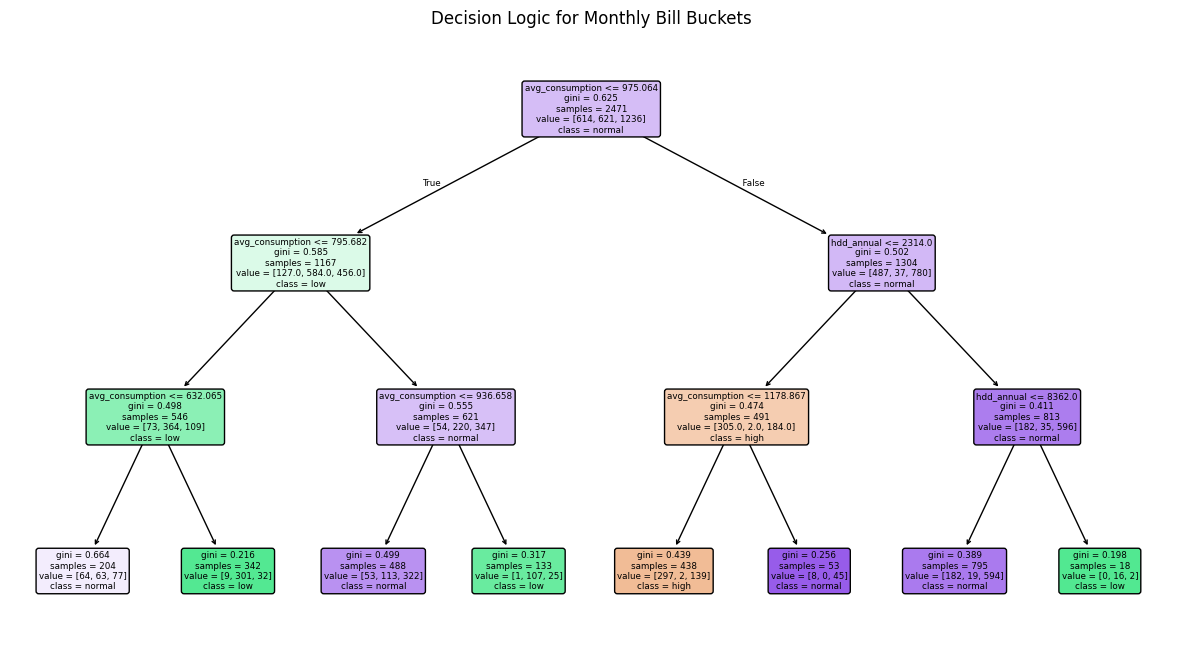

In [34]:
feature_cols = ['rep_margin', 'hdd_annual', 'cdd_annual', 'avg_consumption']

X = df[feature_cols]
y = df['monthly_bill_bucket']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
clf.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(clf, 
          feature_names=feature_cols, 
          class_names=['high', 'low', 'normal'], 
          filled=True, 
          rounded=True)
plt.title("Decision Logic for Monthly Bill Buckets")
plt.show()

In [35]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

           Feature  Importance
3  avg_consumption    0.793886
1       hdd_annual    0.206114
0       rep_margin    0.000000
2       cdd_annual    0.000000


In [36]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

Accuracy: 70.23%


<Figure size 800x600 with 0 Axes>

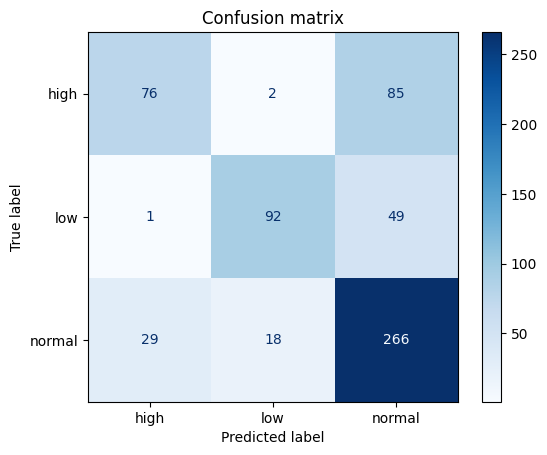

In [37]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, 
                                      display_labels=['high', 'low', 'normal'],
                                      cmap='Blues')
plt.title("Confusion matrix")
plt.show()